# Signal Decomposition: Even & Odd Components

### 🎯 Objective
To decompose a discrete-time signal $x[n]$ into its **Even** ($x_e[n]$) and **Odd** ($x_o[n]$) components.
* **Even Component:** Symmetric around the y-axis ($x_e[n] = x_e[-n]$).
* **Odd Component:** Anti-symmetric around the y-axis ($x_o[n] = -x_o[-n]$).

### 🛠 Description
This notebook demonstrates how to:
1.  **Generate an Exponential Sequence:** $x[n] = a^n u[n]$.
2.  **Implement Helper Functions:**
    * `sigfold`: To calculate time-reversed signal $x[-n]$.
    * `sigadd` & `sigsub`: To handle signal addition and subtraction with different time indices.
3.  **Compute Components:**
    * $x_e[n] = \frac{1}{2} (x[n] + x[-n])$
    * $x_o[n] = \frac{1}{2} (x[n] - x[-n])$
4.  **Visualize:** Plotting the original, even, and odd parts to verify the decomposition.

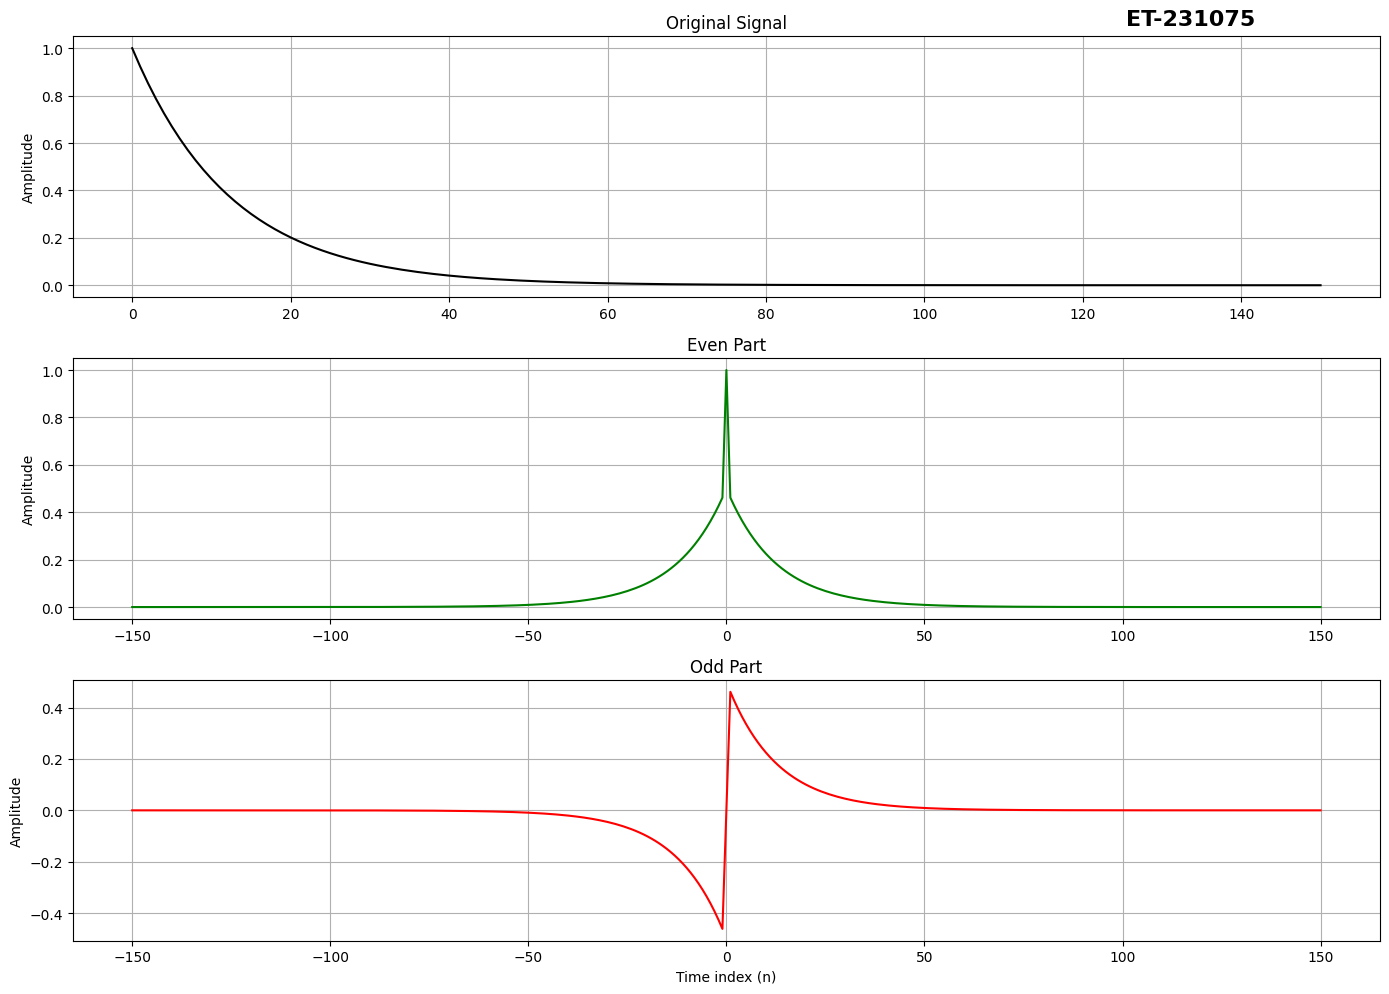

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#Supporting functions
def sigfold(x, n):
    """Implements y(n) = x(-n)"""
    y = np.flip(x)
    n_folded = -np.flip(n)
    return y, n_folded
def sigadd(x1, n1, x2, n2):
    n_min = min(np.min(n1), np.min(n2))
    n_max = max(np.max(n1), np.max(n2))
    n = np.arange(n_min, n_max + 1)
    y1 = np.zeros(len(n))
    y2 = np.zeros(len(n))    
    y1[(n >= np.min(n1)) & (n <= np.max(n1))] = x1
    y2[(n >= np.min(n2)) & (n <= np.max(n2))] = x2
    y = y1 + y2
    return y, n
def sigsub(x1, n1, x2, n2):
    """Subtracts two signals y(n) = x1(n) - x2(n)"""
    n_min = min(np.min(n1), np.min(n2))
    n_max = max(np.max(n1), np.max(n2))
    n = np.arange(n_min, n_max + 1)
    y1 = np.zeros(len(n))
    y2 = np.zeros(len(n))
    y1[(n >= np.min(n1)) & (n <= np.max(n1))] = x1
    y2[(n >= np.min(n2)) & (n <= np.max(n2))] = x2
    y = y1 - y2
    return y, n
def even_odd(x, n):
    #Decomposes x(n) into even xe(n) and odd xo(n) parts#
    # Find x(-n)
    x_fold, n_fold = sigfold(x, n)
    # Even part: xe(n) = 0.5 * (x(n) + x(-n))
    xe, ne = sigadd(x, n, x_fold, n_fold)
    xe = 0.5 * xe
    # Odd part: xo(n) = 0.5 * (x(n) - x(-n))
    xo, no = sigsub(x, n, x_fold, n_fold)
    xo = 0.5 * xo
    return ne, xe, no, xo
#Define ID: ET231075
L = 3
M = 7
N = 5
#Main program
# Generate the exponential sequence
a = (7 + 5) / (7 + 5 + 1.0)  # a = 12 / 13 = 0.923
n_max = (3 + 7 + 5) * 10
n = np.arange(0, n_max + 1)  # n = 0, 1, 2, ..., 150
x = np.power(a, n)  # Signal x(n) = a^n
# Compute even and odd parts
ne, xe, no, xo = even_odd(x, n)
#Plot the signals
plt.figure(figsize=(14, 10))
plt.figtext(0.90, 0.99, "ET-231075", ha="right", va="top", fontsize=16, color="k",fontweight='bold')
# Plot Original Signal
plt.subplot(3, 1, 1)
plt.plot(n, x,'k')  # Using plot for a long sequence is cleaner than stem
plt.title('Original Signal')
plt.ylabel('Amplitude')
plt.grid(True)
# Plot Even Part
plt.subplot(3, 1, 2)
plt.plot(ne, xe,'g')
plt.title('Even Part')
plt.ylabel('Amplitude')
plt.grid(True)
# Plot Odd Part
plt.subplot(3, 1, 3)
plt.plot(no, xo,'r')
plt.title('Odd Part')
plt.xlabel('Time index (n)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()